#  t-Test <hr style="border:2.5px solid #821212"></hr>

<b>Tovi R. Macalipsay</b>
<br>Computer Tech Student

In [46]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [47]:
# load dataset
df = pd.read_csv(r"../dataset/global_gdp_inflation_2000_2024.csv",
                 delimiter=",")
df

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
0,2001,Afghanistan,AFG,-9.431974,NaN,Historical,World Bank API
1,2002,Afghanistan,AFG,28.600001,NaN,Historical,World Bank API
2,2003,Afghanistan,AFG,8.832278,NaN,Historical,World Bank API
3,2004,Afghanistan,AFG,1.414118,NaN,Historical,World Bank API
4,2005,Afghanistan,AFG,11.229715,12.686269,Historical,World Bank API
...,...,...,...,...,...,...,...
5199,2020,Zimbabwe,ZWE,-7.816951,557.201817,Historical,World Bank API
5200,2021,Zimbabwe,ZWE,8.468017,98.546105,Historical,World Bank API
5201,2022,Zimbabwe,ZWE,6.139263,104.705171,Historical,World Bank API
5202,2023,Zimbabwe,ZWE,5.350869,NaN,Historical,World Bank API


In [48]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                5204 non-null   int64  
 1   Country             5204 non-null   object 
 2   ISO3                5204 non-null   object 
 3   GDP_Growth_Percent  5160 non-null   float64
 4   Inflation_Percent   4516 non-null   float64
 5   Data_Type           5204 non-null   object 
 6   Source              5204 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 284.7+ KB


In [49]:
# summary of statistics
df.describe()

,Year,GDP_Growth_Percent,Inflation_Percent
count,5204.000000,5160.000000,4516.000000
mean,2012.060338,3.326306,6.747788
std,7.158901,5.982522,19.938638
min,2000.000000,-54.402093,-16.859691
25%,2006.000000,1.220760,1.625896
50%,2012.000000,3.505123,3.512958
75%,2018.000000,5.803411,7.048209
max,2024.000000,86.826748,557.201817


# Data Cleaning

In [70]:
# Select the 2 countries for comparison
country1 = 'United States'
country2 = 'Philippines'
df = df[df['Country'].isin([country1, country2])]['GDP_Growth_Percent'].dropna()
df

KeyError: 'Country'

In [ ]:
# check for outliers
plt.figure(figsize=(10,5))
plt.boxplot(df)
plt.title('GDP Growth and Inflation')
plt.ylabel('Percent')
#plt.xticks(rotation=45)
plt.show()

KeyError: "None of [Index(['Inflation_Percent', 'GDP_Growth_Percent'], dtype='object')] are in the [index]"

<Figure size 1000x500 with 0 Axes>

In [ ]:
# removing 3-sigma outliers
z_nuclear = stats.zscore()
nuc_outliers = (z_nuclear<-3)|(z_nuclear>3)
df = df[~nuc_outliers]

ValueError: Item wrong length 25 instead of 5204.

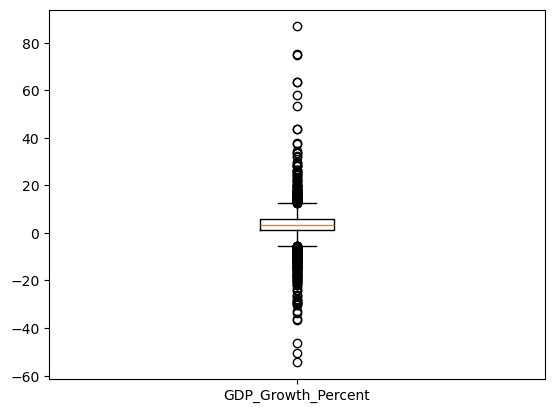

In [53]:
# wind
# removing 3-sigma outliers
z_wind = stats.zscore(df['GDP_Growth_Percent'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]

plt.boxplot(df['GDP_Growth_Percent'].dropna(),tick_labels=['GDP_Growth_Percent'])
plt.show()

In [54]:
# save cleaned dataset
df.to_csv(r"../dataset/global_gdp_inflation_2000_2024_cleaned.csv",
          index=False)

In [55]:
# load dataset
df = pd.read_csv(r"../dataset/global_gdp_inflation_2000_2024_cleaned.csv",
                 delimiter=",")
df

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
0,2001,Afghanistan,AFG,-9.431974,NaN,Historical,World Bank API
1,2002,Afghanistan,AFG,28.600001,NaN,Historical,World Bank API
2,2003,Afghanistan,AFG,8.832278,NaN,Historical,World Bank API
3,2004,Afghanistan,AFG,1.414118,NaN,Historical,World Bank API
4,2005,Afghanistan,AFG,11.229715,12.686269,Historical,World Bank API
...,...,...,...,...,...,...,...
5199,2020,Zimbabwe,ZWE,-7.816951,557.201817,Historical,World Bank API
5200,2021,Zimbabwe,ZWE,8.468017,98.546105,Historical,World Bank API
5201,2022,Zimbabwe,ZWE,6.139263,104.705171,Historical,World Bank API
5202,2023,Zimbabwe,ZWE,5.350869,NaN,Historical,World Bank API


In [56]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                5204 non-null   int64  
 1   Country             5204 non-null   object 
 2   ISO3                5204 non-null   object 
 3   GDP_Growth_Percent  5160 non-null   float64
 4   Inflation_Percent   4516 non-null   float64
 5   Data_Type           5204 non-null   object 
 6   Source              5204 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 284.7+ KB


In [57]:
# summary of statistics
df.describe()

,Year,GDP_Growth_Percent,Inflation_Percent
count,5204.000000,5160.000000,4516.000000
mean,2012.060338,3.326306,6.747788
std,7.158901,5.982522,19.938638
min,2000.000000,-54.402093,-16.859691
25%,2006.000000,1.220760,1.625896
50%,2012.000000,3.505123,3.512958
75%,2018.000000,5.803411,7.048209
max,2024.000000,86.826748,557.201817


# 2-Sample t-Test

## Nuclear and Coal

In [58]:
df[['GDP_Growth_Percent','Inflation_Percent']].describe()

,GDP_Growth_Percent,Inflation_Percent
count,5160.000000,4516.000000
mean,3.326306,6.747788
std,5.982522,19.938638
min,-54.402093,-16.859691
25%,1.220760,1.625896
50%,3.505123,3.512958
75%,5.803411,7.048209
max,86.826748,557.201817


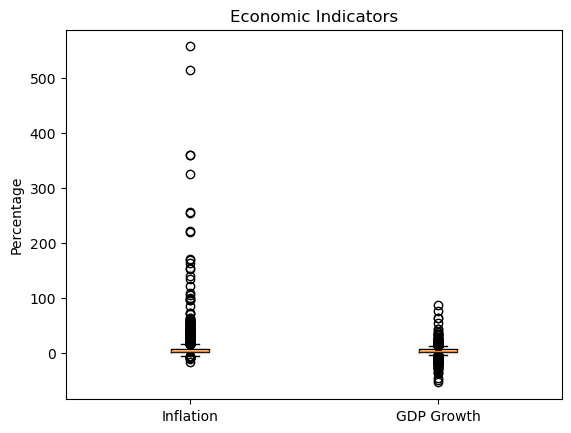

In [59]:
# check for outliers
plt.boxplot(df[['Inflation_Percent','GDP_Growth_Percent']].dropna(),tick_labels=['Inflation','GDP Growth'])
plt.title("Economic Indicators")
plt.ylabel('Percentage')
plt.show()

In [60]:
# shapiro-wilk normality test
print("GDP Growth:")
w_stat, p_value = stats.shapiro(df['GDP_Growth_Percent'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nInflation:")
w_stat, p_value = stats.shapiro(df['Inflation_Percent'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

GDP Growth:
w_stat: nan
P-value: nan
Normal data

Inflation:
w_stat: nan
P-value: nan
Normal data


In [61]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_nuclear = var_coal
Ha: var_nuclear != var_coal
"""

var_nuc = df['Nuclear'].var(ddof=1)
var_coal = df['Coal'].var(ddof=1)

# F-statistic
if var_nuc > var_coal:
    f_stat = var_nuc/var_coal
else:
    f_stat = var_coal/var_nuc

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_nuc = df['Nuclear'].count()-1
dof_coal = df['Coal'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_nuc, dof_coal)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

KeyError: 'Nuclear'

In [ ]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Nuclear <= Coal
Ha: Nuclear > Coal
"""

t_stat, p_value = stats.ttest_ind(df['Nuclear'],df['Coal'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Nuclear-type is better than coal-type.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between nuclear-type and coal-type.")

t_stat = 17.1421
p_value = 0.0000
Nuclear-type is better than coal-type.


In [ ]:
"""
left-tailed test
------------------
Ho: u_nuc = u_coal
Ha: u_nuc > u_coal
"""
    
# cohen's d
nuc_mean = df['Nuclear'].mean()
coal_mean = df['Coal'].mean()
nuc_std = df['Nuclear'].std(ddof=1)

d = abs((nuc_mean - coal_mean)/nuc_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['Nuclear'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 3.7227
Power of the test: 100.00%


# Paired t-Test

In [ ]:
# load dataset
df = pd.read_csv(r"dataset\nuclear-maintenance.csv",
                 delimiter=",")
df

,Before,After
0,1307,1338
1,1288,1260
2,1255,1191
3,1336,1183
4,1238,1345
5,1273,1315
6,1233,1264
7,1337,1317
8,1274,1345
9,1333,1275


In [ ]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Before  49 non-null     int64
 1   After   49 non-null     int64
dtypes: int64(2)
memory usage: 916.0 bytes


In [ ]:
# summary of statistics
df.describe()

,Before,After
count,49.000000,49.000000
mean,1267.408163,1284.714286
std,34.762239,47.050505
min,1197.000000,1183.000000
25%,1242.000000,1258.000000
50%,1268.000000,1283.000000
75%,1293.000000,1328.000000
max,1337.000000,1363.000000


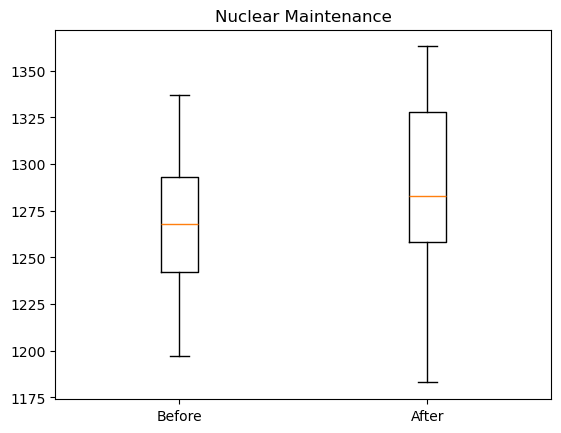

In [ ]:
# check for outliers
plt.boxplot(df[['Before','After']],tick_labels=df.columns)
plt.title("Nuclear Maintenance")
plt.show()

In [ ]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_before = var_after
Ha: var_before != var_after
"""

var_before = df['Before'].var(ddof=1)
var_after = df['After'].var(ddof=1)

# F-statistic
if var_before > var_after:
    f_stat = var_after/var_before
else:
    f_stat = var_before/var_after

print(f'F-statistic = {f_stat:.4f}')

# Degrees of Freedom
dof_before = df['Before'].count()-1
dof_after = df['After'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_before, dof_after)
print(f'p-value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

F-statistic = 0.5459
p-value = 0.9808
equal variances


In [ ]:
"""
Paired T-Test (Nuclear Maintenance)
"""
t_stat, p_value = stats.ttest_rel(df['Before'],df['After'])
print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("There is a significant improvement after the maintenance.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference before and after the maintenance.")

t_stat = -2.0990
p_value = 0.0411
There is a significant improvement after the maintenance.
